# QAOA MaxCut Surrogate-Rate Sweep
This notebook loads trained parameters and evaluates the MaxCut surrogate at different `build_min_abs` (surrogate rate) values.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import torch
from matplotlib import pyplot as plt

# Repo path setup
_THIS_DIR = Path.cwd()
_REPO_ROOT = _THIS_DIR.parent
_TEST_QAOA = _REPO_ROOT / "test_qaoa"
for path in (str(_REPO_ROOT), str(_TEST_QAOA)):
    if path not in sys.path:
        sys.path.insert(0, path)

from src_tensor.api import compile_expval_program
from qaoa_surrogate_common import (
    load_edges_json,
    build_qaoa_circuit,
    build_maxcut_observable,
    expected_cut_from_sum_zz,
 )

# Inputs
checkpoint_path = Path(_REPO_ROOT / "QAOA/artifacts/qaoa_maxcut_30q_steps/step_000000.pt")
edges_path = Path(_REPO_ROOT / "QAOA/artifacts/maxcut_edges.json")
n_qubits = 30
p_layers = 4

# Surrogate rate sweep (build_min_abs)
min_abs_values = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]

# Load trained parameters
payload = torch.load(checkpoint_path, map_location="cpu")

thetas = payload["thetas"].detach().cpu()

# Build circuit and observable
edges = load_edges_json(edges_path)
circuit, n_params = build_qaoa_circuit(n_qubits=n_qubits, edges=edges, p_layers=p_layers)
obs = build_maxcut_observable(n_qubits=n_qubits, edges=edges)
print(f"Edges={len(edges)} | Params={n_params}")

# Device/preset setup
compute_device = "cuda" if torch.cuda.is_available() else "cpu"
preset = "hybrid"
preset_overrides = {
    "memory_device": "cpu",
    "compute_device": compute_device,
    "chunk_size":10000000000000
}

rows = []
for min_abs in min_abs_values:
    program = compile_expval_program(
        circuit=circuit,
        observables=[obs],
        preset=preset,
        preset_overrides=preset_overrides,
        build_thetas=thetas,
        build_min_abs=float(min_abs),
    )
    sum_zz = float(program.expval(thetas, obs_index=0).detach().cpu().item())
    exp_cut = expected_cut_from_sum_zz(sum_zz, len(edges))
    rows.append((float(min_abs), sum_zz, exp_cut))
    print(f"min_abs={min_abs:.2e} | sum<ZZ>={sum_zz:+.8f} | E[cut]={exp_cut:.6f}")

# Plot
x = np.asarray([r[0] for r in rows], dtype=np.float64)
y = np.asarray([r[2] for r in rows], dtype=np.float64)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x, y, marker="o")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("build_min_abs (larger -> more truncation)")
ax.set_ylabel("Expected cut")
ax.set_title("MaxCut Surrogate Rate Sweep")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Edges=153 | Params=8


propagate: 100%|██████████| 762/762 [00:10<00:00, 72.61it/s] 


Starting zero-filtering on cuda...


zero-filter: 100%|██████████| 762/762 [00:03<00:00, 199.54it/s]


min_abs=1.00e-02 | sum<ZZ>=+27.67325783 | E[cut]=62.663371


propagate:  52%|█████▏    | 400/762 [00:05<00:05, 60.61it/s] 

In [4]:
thetas

tensor([ 2.4089e-07, -5.2448e-06, -1.2011e-05, -3.9086e-02, -1.2622e+00,
        -1.6238e-07, -1.7285e-02,  5.6699e-02, -9.2388e-07,  8.2012e-08,
        -5.8022e-07, -4.0872e-07,  8.7817e-07, -1.5708e+00, -7.4832e-07,
        -7.0179e-08, -2.8594e-06,  2.0466e-06, -3.8477e-06, -1.3962e-08,
         8.4517e-08, -1.6926e-07,  3.0988e-07, -5.3920e-07,  4.5882e-07,
        -7.5636e-08,  2.2838e-07, -1.1674e-07, -1.5708e+00, -1.1768e-07,
        -1.0200e-07,  1.5068e-06,  3.5553e-05,  1.2639e-06, -1.5708e+00,
         1.8448e-06,  2.0635e-07, -3.9738e-07,  3.2579e-05,  3.3447e-05,
        -1.5708e+00,  1.9054e-06,  2.0423e-05,  5.5611e-07,  1.3648e-06,
         1.8866e-07, -1.3291e-06, -1.7417e-05,  4.2453e-07,  1.5734e+00,
         2.3348e-02,  1.2032e+00, -2.5295e-07, -9.4413e-07, -6.1752e-07,
         1.6502e-05,  2.8802e-07, -5.5720e-07, -2.2142e-07,  1.4028e-07,
         2.2562e-07,  9.5971e-09, -1.5708e+00, -2.3005e-07, -4.3444e-06,
         2.9047e-06, -2.7860e-05,  2.6949e-06, -2.5

# 10-Qubit PPS vs PennyLane (Exact)
Random QAOA parameters, compare PPS expected value vs PennyLane exact for MaxCut observable.

In [ ]:
import numpy as np
import torch
from pathlib import Path
import sys

# Ensure test_qaoa is on sys.path for qaoa_surrogate_common
_THIS_DIR = Path.cwd()
_REPO_ROOT = _THIS_DIR.parent
_TEST_QAOA = _REPO_ROOT / "test_qaoa"
if str(_TEST_QAOA) not in sys.path:
    sys.path.insert(0, str(_TEST_QAOA))

from qaoa_surrogate_common import (
    make_ring_chord_graph,
    build_qaoa_circuit,
    build_maxcut_observable,
    expected_cut_from_sum_zz,
 )
from src_tensor.api import compile_expval_program

# 10-qubit MaxCut test with random parameters
n_qubits_test = 10
p_layers_test = 4
seed = 123
rng = np.random.default_rng(seed)

edges_test = edges
obs_test = build_maxcut_observable(n_qubits=n_qubits_test, edges=edges_test)
circuit_test = circuit
thetas_np = payload["best_thetas"].detach().cpu()
thetas = torch.tensor(thetas_np, dtype=torch.float64)

# PPS compile and expval
program_test = compile_expval_program(
    circuit=circuit_test,
    observables=[obs_test],
    preset="gpu",
    preset_overrides={"memory_device": "cpu", "compute_device": "cuda",'chunk_size':100000000},
    build_thetas=thetas,
    build_min_abs=1e-3,
 )
pps_sum_zz = float(program_test.expval(thetas, obs_index=0).detach().cpu().item())
pps_exp_cut = expected_cut_from_sum_zz(pps_sum_zz, len(edges_test))

# PennyLane exact expval (n_qubits <= 20)
pl_vals = program_test.expvals_pennylane(thetas, max_qubits=20)
pl_sum_zz = float(pl_vals[0].detach().cpu().item())
pl_exp_cut = expected_cut_from_sum_zz(pl_sum_zz, len(edges_test))

print(f"Edges={len(edges_test)} | Params={n_params_test}")
print(f"PPS sum<ZZ>   = {pps_sum_zz:+.10f} | E[cut]={pps_exp_cut:.6f}")
print(f"Exact sum<ZZ> = {pl_sum_zz:+.10f} | E[cut]={pl_exp_cut:.6f}")
print(f"Abs diff sum<ZZ> = {abs(pps_sum_zz - pl_sum_zz):.3e}")

/tmp/ipykernel_1868088/2125510013.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  thetas = torch.tensor(thetas_np, dtype=torch.float64)
propagate: 100%|██████████| 190/190 [00:02<00:00, 82.40it/s]


Starting zero-filtering on cuda...


zero-filter: 100%|██████████| 190/190 [00:00<00:00, 267.05it/s]


Edges=35 | Params=60
PPS sum<ZZ>   = -5.9378726652 | E[cut]=20.468936
Exact sum<ZZ> = -6.1448594166 | E[cut]=20.572430
Abs diff sum<ZZ> = 2.070e-01


: 

/home/quantum/anaconda3/envs/cudaq/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


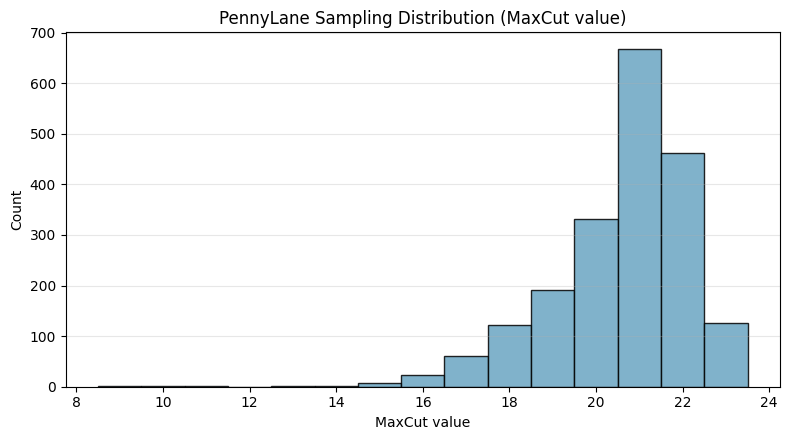

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from src_tensor.api import pennylane_sample_small
from qaoa_surrogate_common import cut_value_from_bits

# PennyLane sampling and MaxCut distribution
shots = 2000
samples = pennylane_sample_small(
    circuit=circuit_test,
    thetas=thetas,
    n_qubits=n_qubits_test,
    shots=shots,
    max_qubits=20,
    seed=seed,
 )
samples_np = samples.detach().cpu().numpy().astype(np.uint8)
cuts = np.asarray([cut_value_from_bits(row.tolist(), edges_test) for row in samples_np], dtype=np.int64)

bins = np.arange(int(cuts.min()), int(cuts.max()) + 2) - 0.5
fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.hist(cuts, bins=bins, color="#6aa5c2", edgecolor="black", alpha=0.85)
ax.set_xlabel("MaxCut value")
ax.set_ylabel("Count")
ax.set_title("PennyLane Sampling Distribution (MaxCut value)")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()